# Integrantes
- Christopher Andres Obando Rivera
- Mateo Murcia Valles

# Análisis Exploratorio — Proyecto 2: Clasificación

**Dataset:** Spambase — UCI Machine Learning Repository  
**Objetivo:** Clasificar correos electrónicos como spam (1) o no spam (0)

## Descripción del dataset

El dataset contiene **4,601 correos electrónicos** con **57 características** extraídas del contenido de cada correo:

| Grupo | Variables | Descripción |
|---|---|---|
| Frecuencia de palabras | 48 | % de veces que aparece cada palabra en el correo |
| Frecuencia de caracteres | 6 | % de veces que aparece cada caracter (`;`, `(`, `[`, `!`, `$`, `#`) |
| Secuencias de mayúsculas | 3 | Longitud promedio, máxima y total de secuencias en mayúsculas |

**Variable objetivo:** `spam` → 1 = spam, 0 = no spam

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

sns.set_theme(style='whitegrid')

data = fetch_openml(name='spambase', version=1, as_frame=True)
df = data.frame
df['class'] = df['class'].astype(int)
df = df.rename(columns={'class': 'spam'})

print(f'Dimensiones: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
df.info()

Dimensiones: (4601, 58)
Valores nulos: 0
<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  wor

# 1. Balance de clases

BALANCE DE CLASES
No spam (0): 2,788 correos (60.6%)
Spam    (1): 1,813 correos (39.4%)
Total      : 4,601 correos


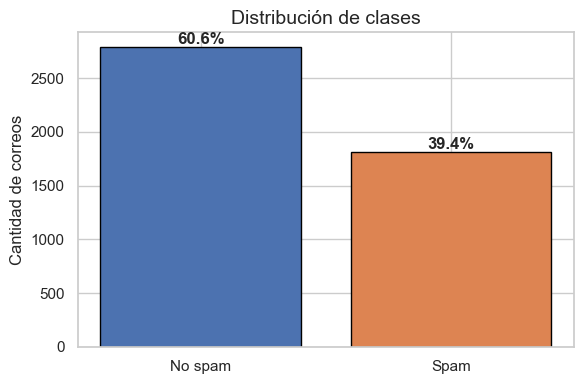

In [2]:
conteo = df['spam'].value_counts()
pct = df['spam'].value_counts(normalize=True) * 100

print('BALANCE DE CLASES')
print(f'No spam (0): {conteo[0]:,} correos ({pct[0]:.1f}%)')
print(f'Spam    (1): {conteo[1]:,} correos ({pct[1]:.1f}%)')
print(f'Total      : {len(df):,} correos')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No spam', 'Spam'], conteo.values, color=['#4C72B0', '#DD8452'], edgecolor='black')
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{p:.1f}%', ha='center', fontweight='bold')
ax.set_title('Distribución de clases', fontsize=14)
ax.set_ylabel('Cantidad de correos')
plt.tight_layout()
plt.show()

# 2. Estadísticas descriptivas

In [3]:
display(df.describe().round(3))

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,...,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000
mean,0.105,0.213,0.281,0.065,0.312,0.096,0.114,0.105,0.090,0.239,...,0.039,0.139,0.017,0.269,0.076,0.044,5.192,52.173,283.289,0.394
std,0.305,1.291,0.504,1.395,0.673,0.274,0.391,0.401,0.279,0.645,...,0.243,0.270,0.109,0.816,0.246,0.429,31.729,194.891,606.348,0.489
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,1.588,6.000,35.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.065,0.000,0.000,0.000,0.000,2.276,15.000,95.000,0.000
75%,0.000,0.000,0.420,0.000,0.380,0.000,0.000,0.000,0.000,0.160,...,0.000,0.188,0.000,0.315,0.052,0.000,3.706,43.000,266.000,1.000
max,4.540,14.280,5.100,42.810,10.000,5.880,7.270,11.110,5.260,18.180,...,4.385,9.752,4.081,32.478,6.003,19.829,1102.500,9989.000,15841.000,1.000


# 3. Palabras más discriminantes entre spam y no spam

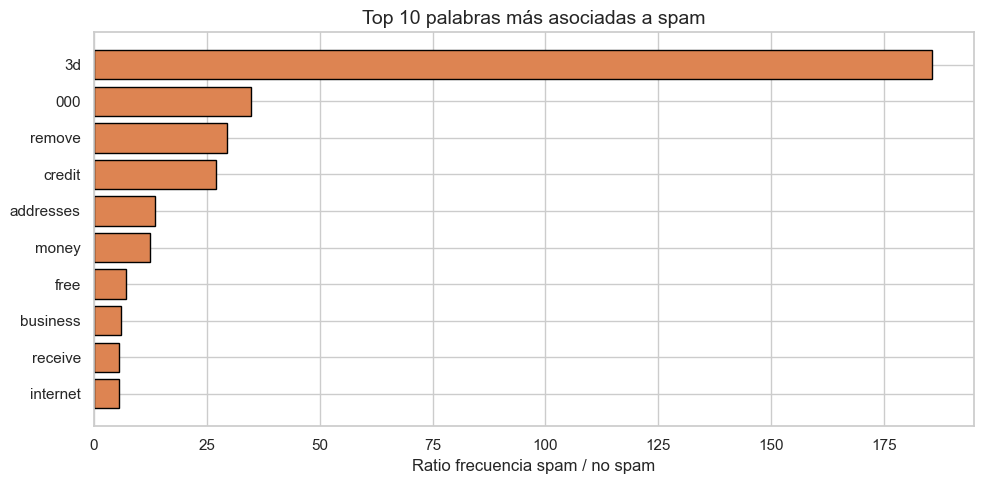


Palabras con mayor ratio spam/no-spam:
  "3d": 185.7x más frecuente en spam
  "000": 34.9x más frecuente en spam
  "remove": 29.3x más frecuente en spam
  "credit": 27.1x más frecuente en spam
  "addresses": 13.5x más frecuente en spam
  "money": 12.4x más frecuente en spam
  "free": 7.0x más frecuente en spam
  "business": 5.9x más frecuente en spam
  "receive": 5.5x más frecuente en spam
  "internet": 5.4x más frecuente en spam


In [4]:
word_cols = [c for c in df.columns if c.startswith('word_freq_')]

medias_spam = df[df['spam']==1][word_cols].mean()
medias_ham  = df[df['spam']==0][word_cols].mean()
ratio = (medias_spam / (medias_ham + 1e-6)).sort_values(ascending=False)

top10 = ratio.head(10)
labels = [c.replace('word_freq_', '') for c in top10.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels[::-1], top10.values[::-1], color='#DD8452', edgecolor='black')
ax.set_xlabel('Ratio frecuencia spam / no spam')
ax.set_title('Top 10 palabras más asociadas a spam', fontsize=14)
plt.tight_layout()
plt.show()

print('\nPalabras con mayor ratio spam/no-spam:')
for word, val in zip(labels, top10.values):
    print(f'  "{word}": {val:.1f}x más frecuente en spam')

# 4. Distribución de variables clave

In [7]:
# Ver nombres exactos de columnas
print([c for c in df.columns if 'char' in c])

['char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_freq_%21', 'char_freq_%24', 'char_freq_%23']


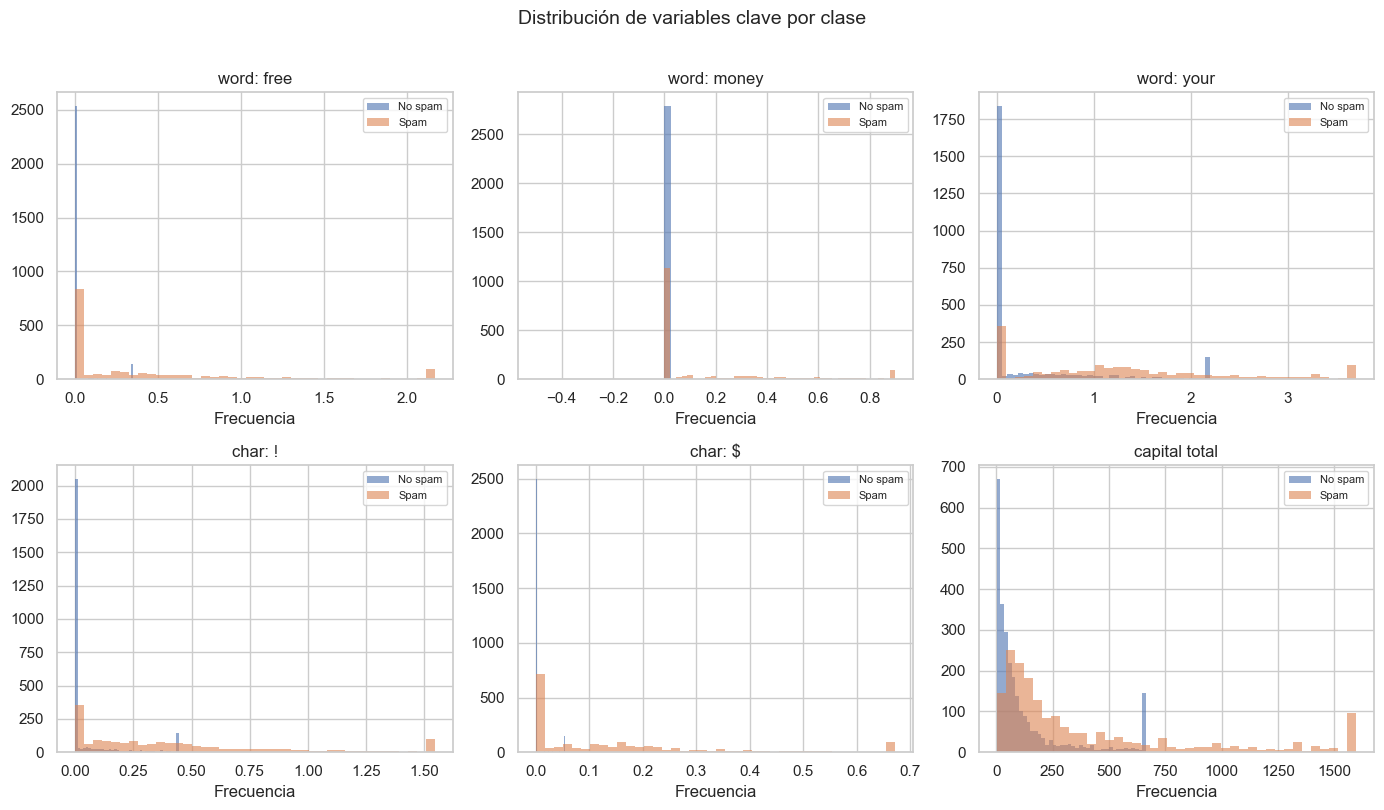

In [8]:
vars_interes = [
    'word_freq_free', 'word_freq_money', 'word_freq_your',
    'char_freq_%21', 'char_freq_%24', 'capital_run_length_total'
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

nombres = ['word: free', 'word: money', 'word: your',
           'char: !', 'char: $', 'capital total']

for i, (col, nombre) in enumerate(zip(vars_interes, nombres)):
    for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
        subset = df[df['spam']==label][col]
        subset_clip = subset.clip(upper=subset.quantile(0.95))
        axes[i].hist(subset_clip, bins=40, alpha=0.6, color=color,
                     label='No spam' if label==0 else 'Spam', edgecolor='none')
    axes[i].set_title(nombre)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Frecuencia')

plt.suptitle('Distribución de variables clave por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 5. Correlación entre variables y spam

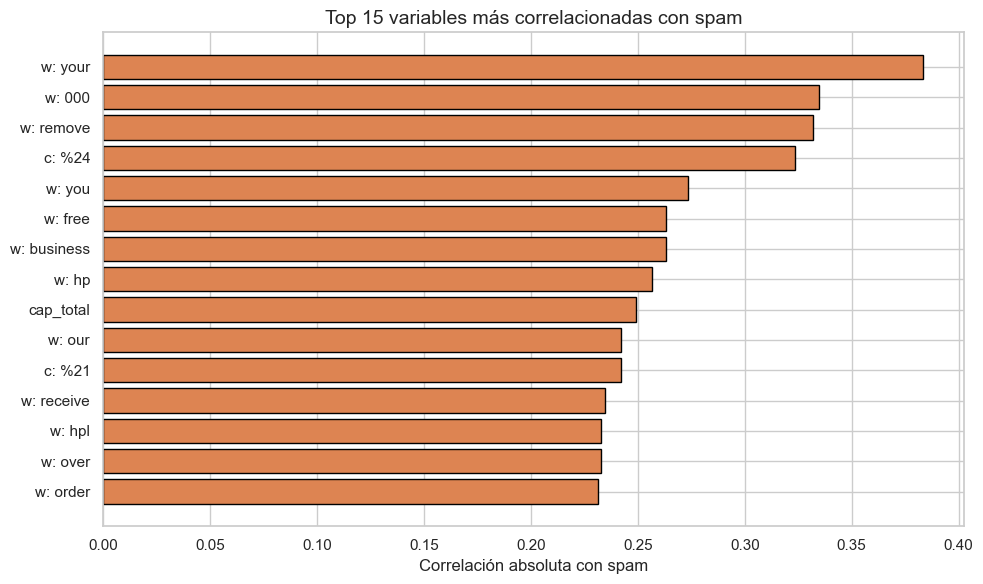

TOP 15 variables más correlacionadas con spam:
  word_freq_your: 0.383
  word_freq_000: 0.335
  word_freq_remove: 0.332
  char_freq_%24: 0.324
  word_freq_you: 0.274
  word_freq_free: 0.263
  word_freq_business: 0.263
  word_freq_hp: 0.257
  capital_run_length_total: 0.249
  word_freq_our: 0.242
  char_freq_%21: 0.242
  word_freq_receive: 0.235
  word_freq_hpl: 0.233
  word_freq_over: 0.233
  word_freq_order: 0.232


In [9]:
correlaciones = df.corr()['spam'].drop('spam').abs().sort_values(ascending=False)
top15 = correlaciones.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if correlaciones[c] > 0 else '#4C72B0' for c in top15.index]
ax.barh([c.replace('word_freq_','w: ').replace('char_freq_','c: ').replace('capital_run_length_','cap_') 
         for c in top15.index[::-1]], 
        top15.values[::-1], color=colors[::-1], edgecolor='black')
ax.set_xlabel('Correlación absoluta con spam')
ax.set_title('Top 15 variables más correlacionadas con spam', fontsize=14)
plt.tight_layout()
plt.show()

print('TOP 15 variables más correlacionadas con spam:')
for var, val in top15.items():
    print(f'  {var}: {val:.3f}')

# 6. Preparación para modelado

Con base en el EDA, identificamos los siguientes puntos clave antes de entrenar los modelos:

- **Balance de clases:** 60.6% no spam / 39.4% spam — aceptable, no requiere balanceo
- **Sin valores nulos:** el dataset está limpio
- **Variables sesgadas:** la mayoría tienen muchos ceros (distribución asimétrica). Se recomienda aplicar `log(x + 0.1)` antes de SVM y Regresión Logística
- **Variables más predictivas:** `char_freq_!`, `char_freq_$`, `word_freq_free`, `capital_run_length_total`

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train_log = np.log1p(X_train)
X_test_log  = np.log1p(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled  = scaler.transform(X_test_log)

print('DATOS LISTOS PARA MODELADO')
print(f'Entrenamiento: {X_train.shape[0]:,} correos')
print(f'Prueba:        {X_test.shape[0]:,} correos')
print(f'Features:      {X_train.shape[1]}')
print(f'\nDistribución en entrenamiento:')
print(f'  No spam: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'  Spam:    {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')

DATOS LISTOS PARA MODELADO
Entrenamiento: 3,220 correos
Prueba:        1,381 correos
Features:      57

Distribución en entrenamiento:
  No spam: 1,951 (60.6%)
  Spam:    1,269 (39.4%)


### A tener en cuenta:
Balanceo de datos
Comparar metodos de clasificación
1. Sin balanceo y con balanceo(smote)
2. Metricas de evaluación